# gphistosys vs histosys

This notebook compares the standard `histosys` modifier (piecewise-linear interpolation
between a lo and hi template at α = ±1) against the new `gphistosys` modifier
(GP posterior-mean interpolation through arbitrary anchor nodes).

Two `gphistosys` scenarios are shown:
- **2 nodes** at α = ±1 — same anchors as histosys, but smoother interpolation
- **3 nodes** at α = {−1, 0, +1} — an extra mid-point template that histosys cannot express

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pyhf

## Common model data

In [29]:
NOM  = [100.0, 150.0]   # nominal background
LO   = [ 80.0, 130.0]   # template at alpha = -1
HI   = [120.0, 175.0]   # template at alpha = +1
SIG  = [ 30.0,  95.0]   # signal
DATA = [120.0, 180.0]   # observed

## Build workspaces

In [30]:
def make_histosys_ws():
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [{"name": "alpha", "type": "histosys",
                             "data": {"lo_data": LO, "hi_data": HI}}]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


def make_gphistosys_ws(nodes, templates):
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [{"name": "alpha", "type": "gphistosys",
                             "data": {"nodes":     [[n] for n in nodes],
                                      "templates": templates}}]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


modifier_set = pyhf.modifiers.histfactory_set

histo_model = pyhf.Workspace(make_histosys_ws()).model(modifier_set=modifier_set,
                                                      modifier_settings={'histosys': {'interpcode': 'code4p'}})

# 3 nodes — extra kink at alpha=0
gp_model = pyhf.Workspace(
    make_gphistosys_ws([-1.0, 0.0, 1.0], [LO, NOM, HI])
).model(modifier_set=modifier_set,
    modifier_settings={'gphistosys': {'length_scale': 100.0, 'noise': 0.0}}, validate=False)

print('par order (histosys):', histo_model.config.par_order)
print('par order (gphistosys):', gp_model.config.par_order)

par order (histosys): ['alpha', 'mu']
par order (gphistosys): ['alpha', 'mu']


## Sweep alpha and compare interpolated yields

In [31]:
alphas = np.linspace(-2.0, 2.0, 200)


def sweep_background(model, alphas, modifier_name='alpha'):
    """Expected total yield as a function of alpha with mu=0 (signal off)."""
    mu_idx   = model.config.par_map['mu']['slice'].start
    al_start = model.config.par_map[modifier_name]['slice'].start
    out = []
    for a in alphas:
        pars = model.config.suggested_init()
        pars[mu_idx]   = 0.0
        pars[al_start] = a
        out.append(model.expected_actualdata(pars))
    return np.array(out)


y_histo = sweep_background(histo_model, alphas)
y_gp3   = sweep_background(gp_model,   alphas)

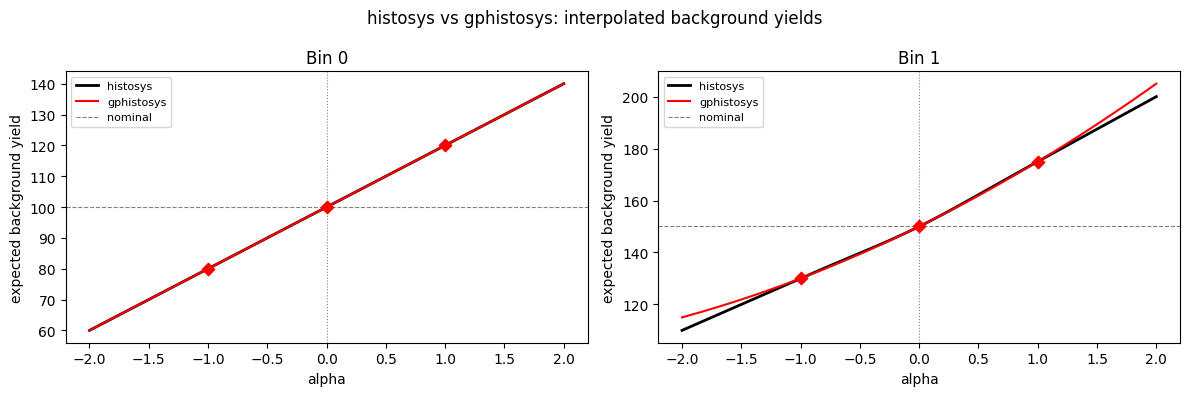

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bin_idx, ax in enumerate(axes):
    ax.plot(alphas, y_histo[:, bin_idx], 'k-',  lw=2,   label='histosys')
    ax.plot(alphas, y_gp3  [:, bin_idx], 'r-',  lw=1.5, label='gphistosys')

    # Mark anchor points
    ax.scatter([-1.0, 0.0, 1.0],    [LO[bin_idx], NOM[bin_idx], HI[bin_idx]], color='red',  zorder=5, s=40, marker='D')

    ax.axvline(0,             color='grey', lw=0.8, ls=':')
    ax.axhline(NOM[bin_idx],  color='grey', lw=0.8, ls='--', label='nominal')
    ax.set_xlabel('alpha')
    ax.set_ylabel('expected background yield')
    ax.set_title(f'Bin {bin_idx}')
    ax.legend(fontsize=8)

plt.suptitle('histosys vs gphistosys: interpolated background yields', fontsize=12)
plt.tight_layout()
plt.show()

**What to observe:**
- All three curves pass through the same anchor points at α = ±1
- `histosys` is piecewise-linear (kink at α = 0)
- `gphistosys` with 2 nodes is smooth but overshoots outside ±1 (GP extrapolation)
- `gphistosys` with 3 nodes is pulled through `KINK` at α = 0 — a non-linear shape histosys cannot represent

## Fit comparison

In [35]:
# histosys has a Gaussian constraint on alpha → one auxdata point
# gphistosys uses unconstrained alpha → no auxdata
obs_histo = DATA + histo_model.config.auxdata
obs_gp3   = DATA + gp_model.config.auxdata

pars_histo, nll_histo = pyhf.infer.mle.fit(obs_histo, histo_model, return_fitted_val=True)
pars_gp3,   nll_gp3   = pyhf.infer.mle.fit(obs_gp3,   gp_model,   return_fitted_val=True)


def print_result(label, pars, nll, model):
    print(f'{label}  (2*NLL = {float(nll):.4f})')
    for name, val in zip(model.config.par_order, pars):
        print(f'  {name:15s} = {float(val):+.4f}')
    print()


print_result('histosys',             pars_histo, nll_histo, histo_model)
print_result('gphistosys', pars_gp3,   nll_gp3,   gp_model)

histosys  (2*NLL = 15.8827)
  alpha           = +0.4466
  mu              = +0.2241

gphistosys  (2*NLL = 13.6585)
  alpha           = +0.8619
  mu              = +0.0921

